In [9]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
import time
import gget
import anndata as an
import scanpy as sc
import scanpy.external as sce
import h5py
import scipy
from tqdm import tqdm
import rapids_singlecell as rsc

import rmm
import cupy as cp
from rmm.allocators.cupy import rmm_cupy_allocator

rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 2

In [3]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
sc.logging.print_memory_usage()
adata

Memory usage: current 2.38 GB, difference +2.38 GB
CPU times: user 579 ms, sys: 1.7 s, total: 2.28 s
Wall time: 5.12 s


/nfs/turbo/umms-indikar/Jillian/conda-envs/rapids/lib/python3.13/site-packages/anndata/logging.py:57: FutureWarning: The specified parameters ('newline',) are no longer positional. Please specify them like `newline=False`
  print(format_memory_usage(get_memory_usage(), msg, newline))


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

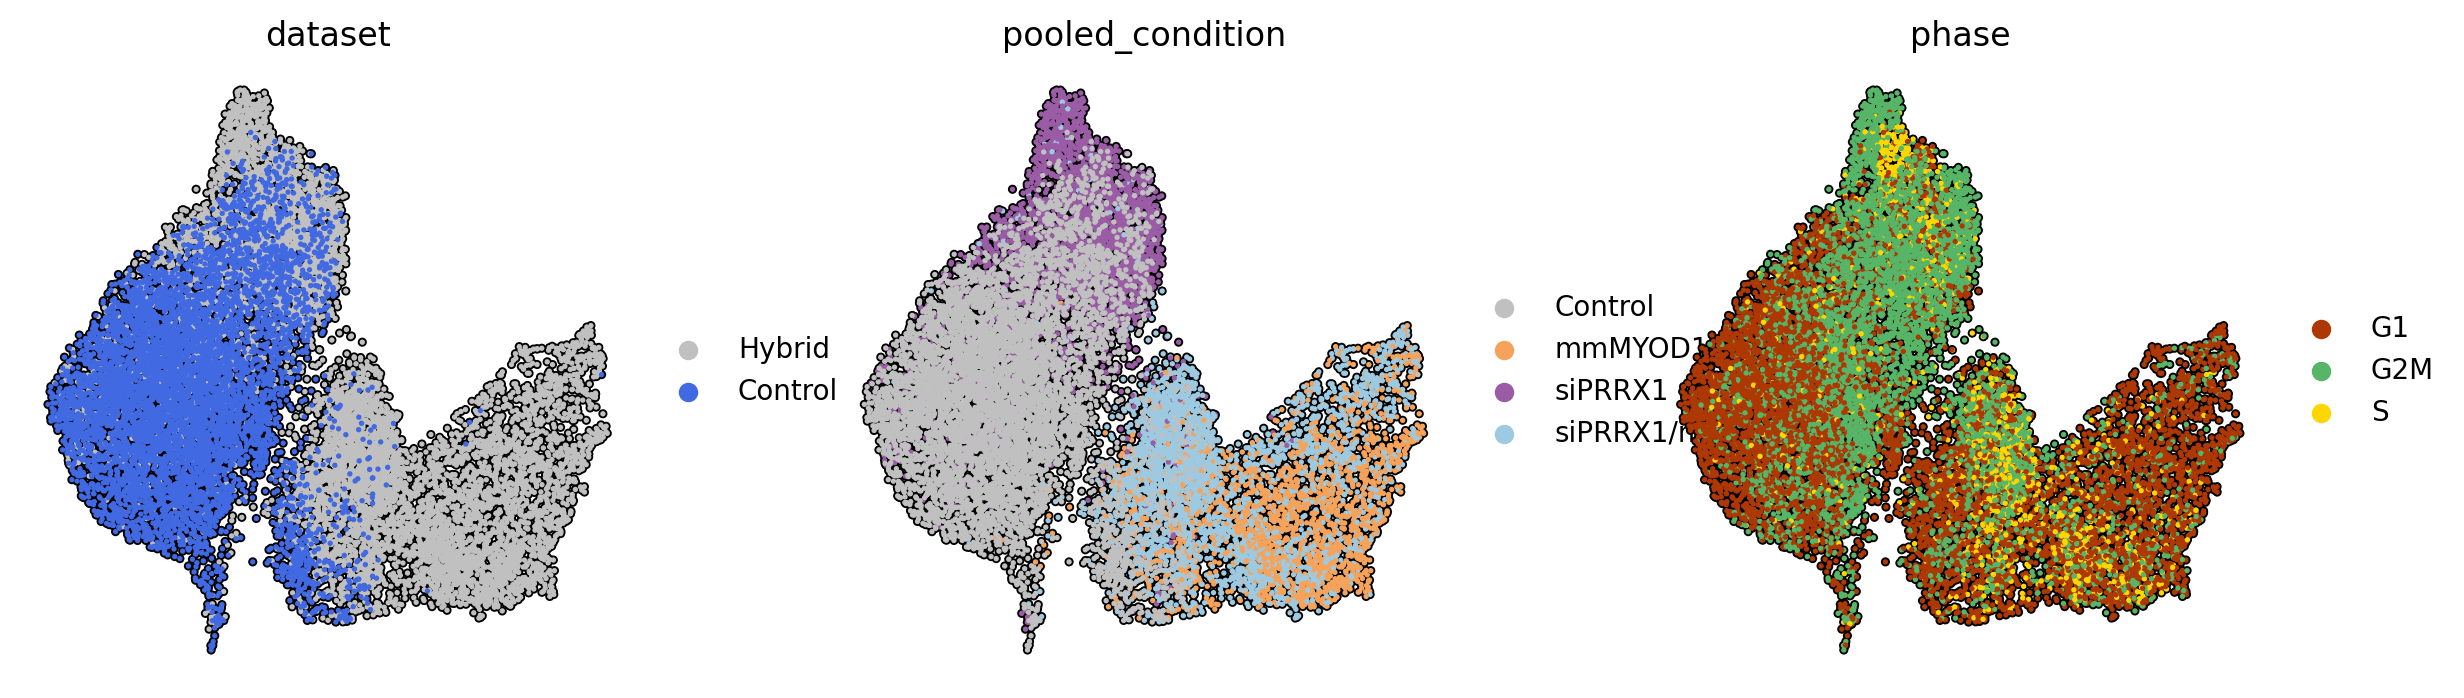

In [4]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'phase'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

# Just mmMYOD1

In [26]:
mdata = adata[adata.obs['pooled_condition'] != 'siPRRX1'].copy()
mdata

AnnData object with n_obs × n_vars = 12520 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

extracting highly variable genes
Number of HVG: 2000


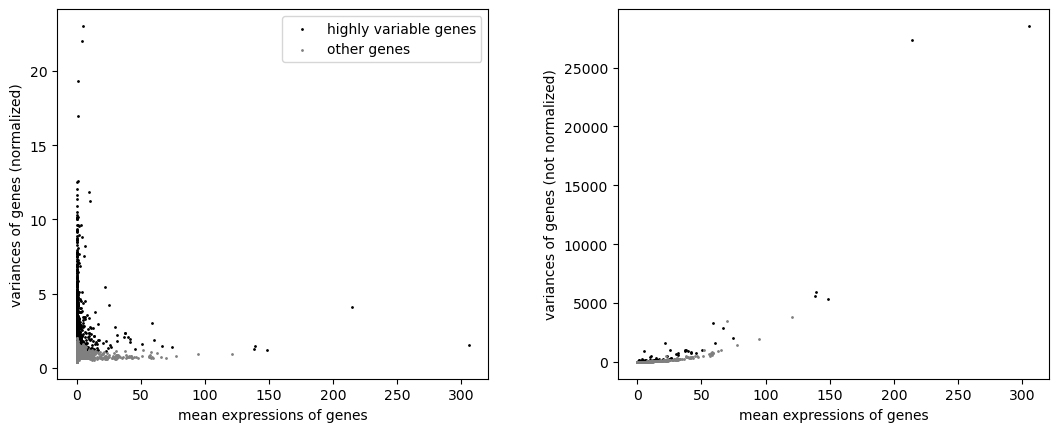

computing PCA
    with n_comps=50
    finished (0:00:19)


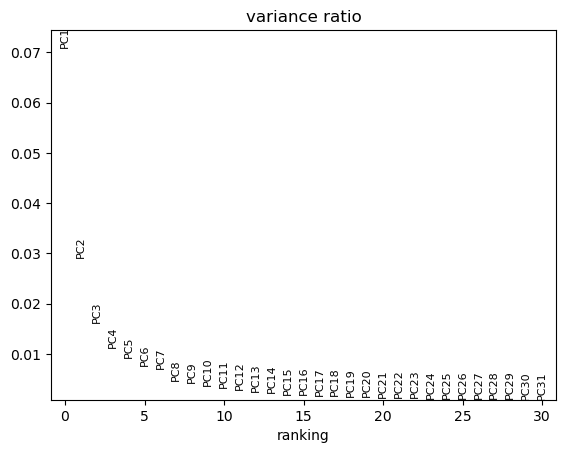

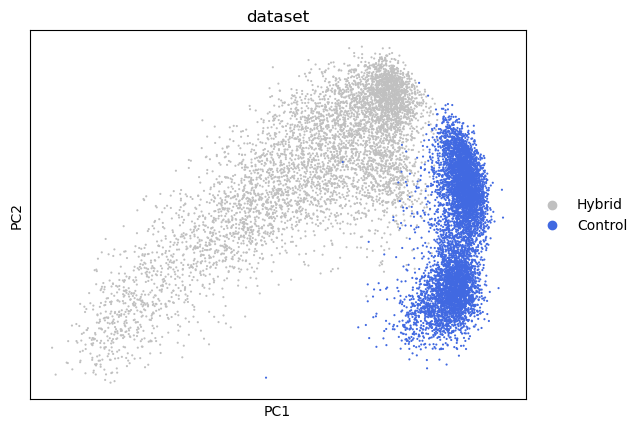

2025-10-17 15:41:54,871 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-17 15:41:54 | [INFO] Computing initial centroids with sklearn.KMeans...
2025-10-17 15:41:57,706 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-17 15:41:57 | [INFO] sklearn.KMeans initialization complete.
2025-10-17 15:41:57,773 - harmonypy - INFO - Iteration 1 of 10
2025-10-17 15:41:57 | [INFO] Iteration 1 of 10
2025-10-17 15:42:00,706 - harmonypy - INFO - Iteration 2 of 10
2025-10-17 15:42:00 | [INFO] Iteration 2 of 10
2025-10-17 15:42:03,903 - harmonypy - INFO - Converged after 2 iterations
2025-10-17 15:42:03 | [INFO] Converged after 2 iterations


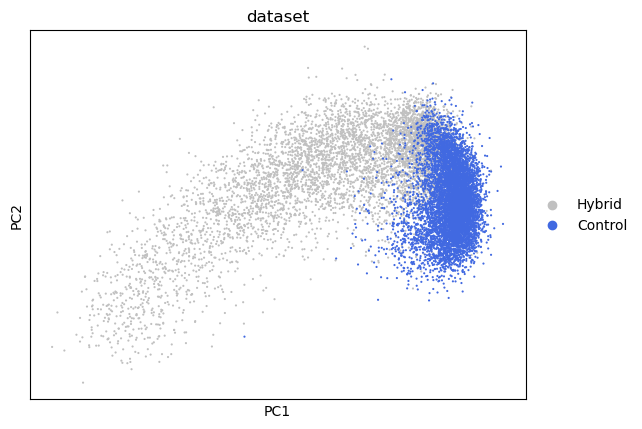

In [27]:
mdata.X = mdata.layers['raw_counts'].copy()

sc.pp.highly_variable_genes(
    mdata,
    flavor='seurat_v3',
    batch_key='dataset',
)

print(f"Number of HVG: {mdata.var['highly_variable'].sum()}")

plt.rcdefaults()
sc.pl.highly_variable_genes(mdata)

mdata.X = mdata.layers['log_norm'].copy()

sc.pp.pca(
    mdata,
    mask_var='filter_pass',
)

sc.pl.pca_variance_ratio(mdata)
sc.pl.pca(mdata, color='dataset')

sce.pp.harmony_integrate(mdata, key=['dataset', 'phase'])

# Save original PCA space
mdata.obsm["X_pca_original"] = mdata.obsm["X_pca"].copy()
mdata.obsm["X_pca"] = mdata.obsm["X_pca_harmony"].copy()

sc.pl.pca(mdata, color='dataset')

running Leiden clustering
    finished (0:00:00)


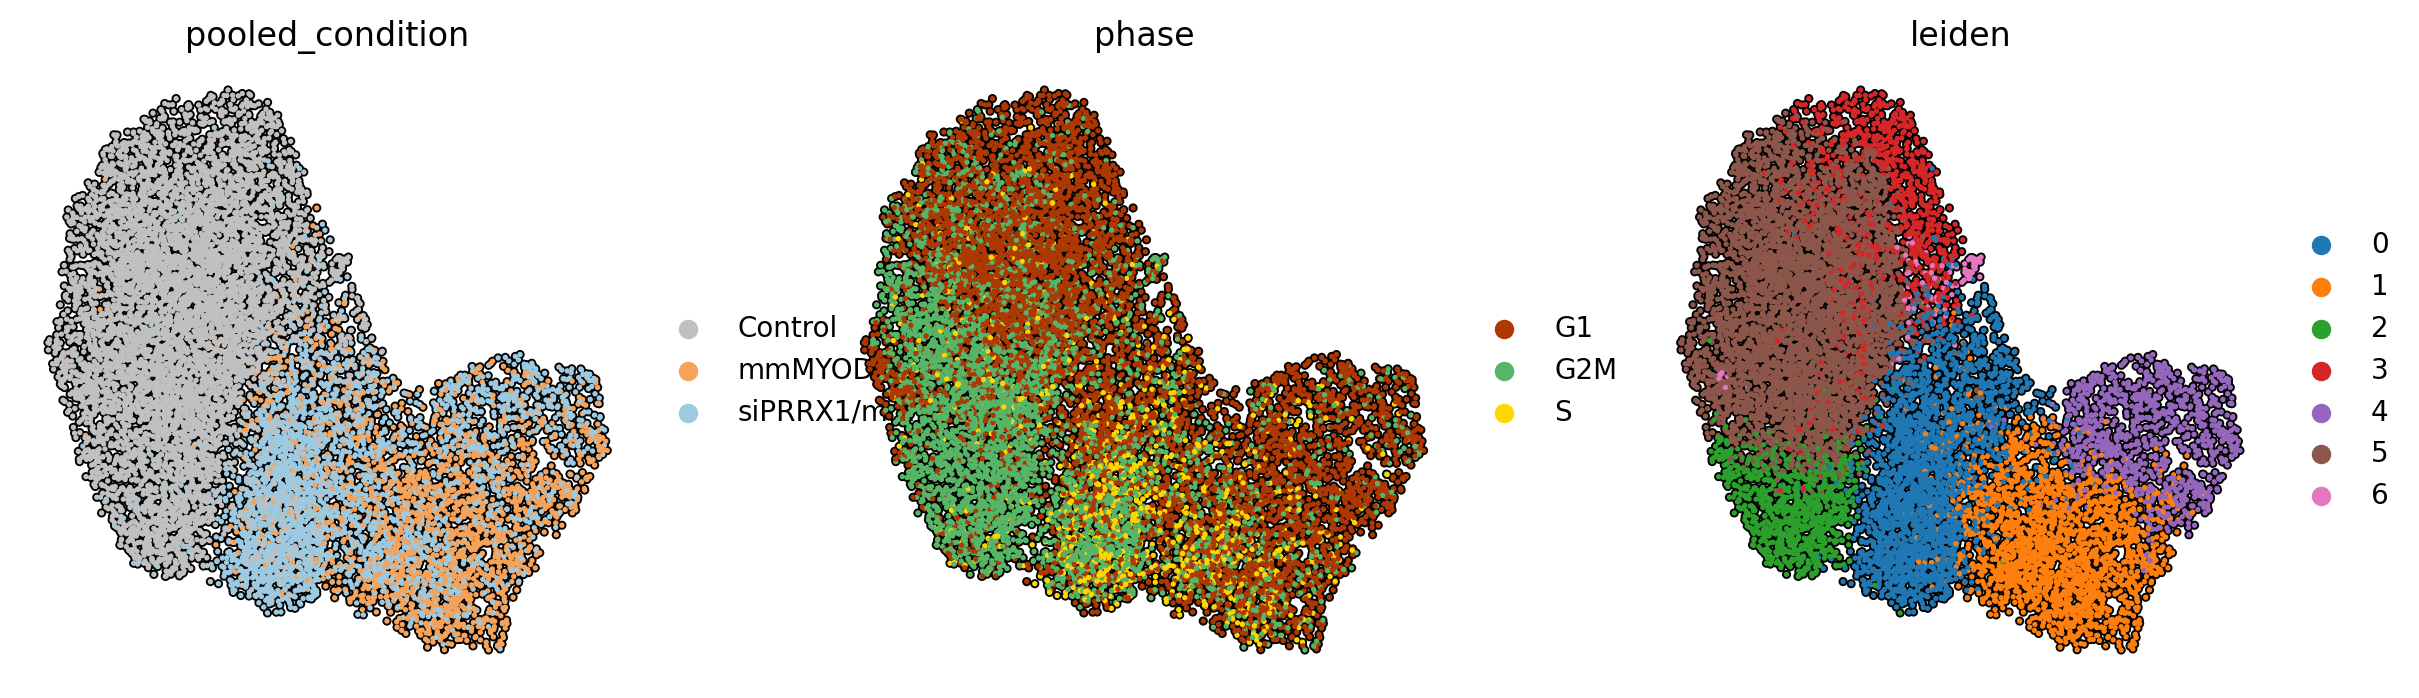

In [28]:
rsc.get.anndata_to_GPU(mdata)

rsc.pp.neighbors(
    mdata,
    use_rep='X_pca_harmony',
    n_neighbors=10,
    n_pcs=30,
)

rsc.tl.umap(
    mdata,
    # min_dist=0.25,
)

rsc.get.anndata_to_CPU(mdata)

sc.tl.leiden(
    mdata,
    resolution=0.4,
    flavor='igraph',
)

plt.rcdefaults()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    mdata,
    color=['pooled_condition', 'phase', 'leiden'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

running PAGA
    finished (0:00:00)


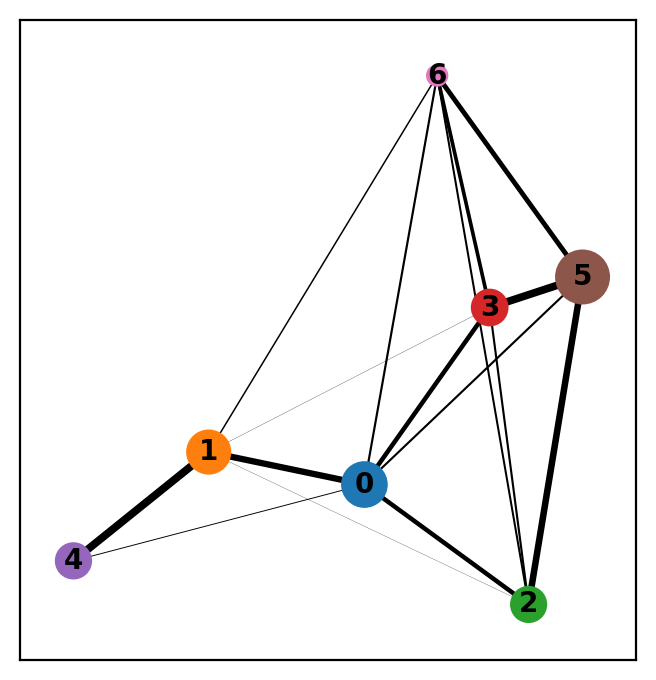

In [29]:
sc.tl.paga(mdata, groups='leiden')
sc.pl.paga(mdata, color=['leiden'])

In [30]:
def find_closest_cell(adata, obs_key='phase', value='G1', obsm_key='X_pca', dataset=None):
    """
    Find the cell closest to a median vector in PCA space for a given group and optional dataset.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group.
        value (str): The value for aggregation (e.g., 'G1').
        obsm_key (str): Key in adata.obsm for PCA or other embedding (e.g., 'X_pca').
        dataset (str, optional): Name of dataset in adata.obs['dataset'] to restrict search.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest matching cell in adata.obs_names.
    """
    mask = adata.obs[obs_key] == value
    if dataset is not None:
        mask &= adata.obs['dataset'] == dataset

    emb = adata.obsm[obsm_key][mask]
    
    if emb.shape[0] == 0:
        raise ValueError("No cells match the specified filters.")

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index

In [31]:
pdata = mdata.copy()

cell_id, root_idx = find_closest_cell(pdata, value='G1', obsm_key='X_pca_harmony', dataset='Control')
print(cell_id, root_idx)

CCAGTATGTTTGGAAG_control 8139


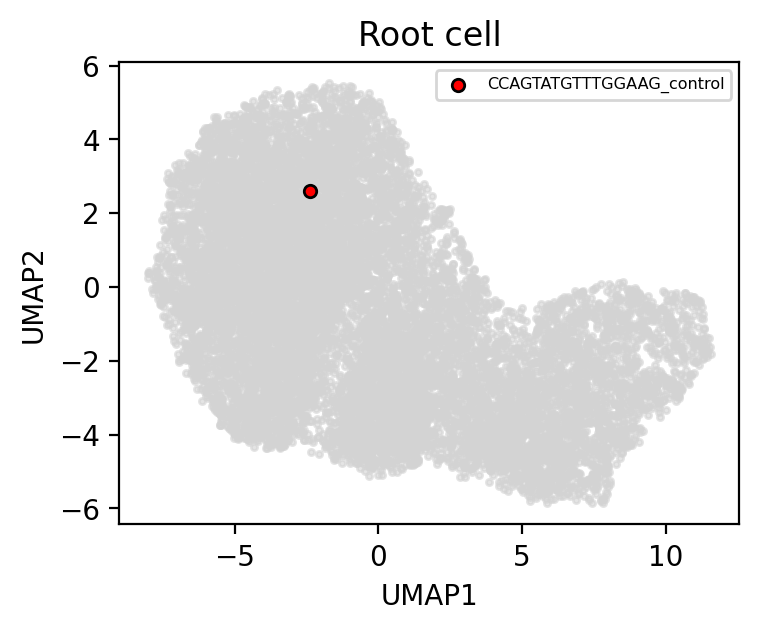

In [33]:
umap = pdata.obsm["X_umap"]
x, y = umap[:, 0], umap[:, 1]

# Plot all cells
plt.figure(figsize=(4, 3))
plt.scatter(x, y, s=5, color='lightgray', alpha=0.6)

# Highlight your cell
plt.scatter(x[root_idx], y[root_idx], s=20, color='red', edgecolor='black', label=cell_id)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.legend(fontsize='xx-small')
plt.title("Root cell")
plt.show()

computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.99162096 0.97493637 0.96214163 0.9557162  0.9531454
     0.9498539  0.94632167 0.9425346  0.9406811  0.9361205  0.92502534
     0.917529   0.9170797  0.9129114 ]
    finished (0:00:00)
computing Diffusion Pseudotime using n_dcs=15
    finished (0:00:00)


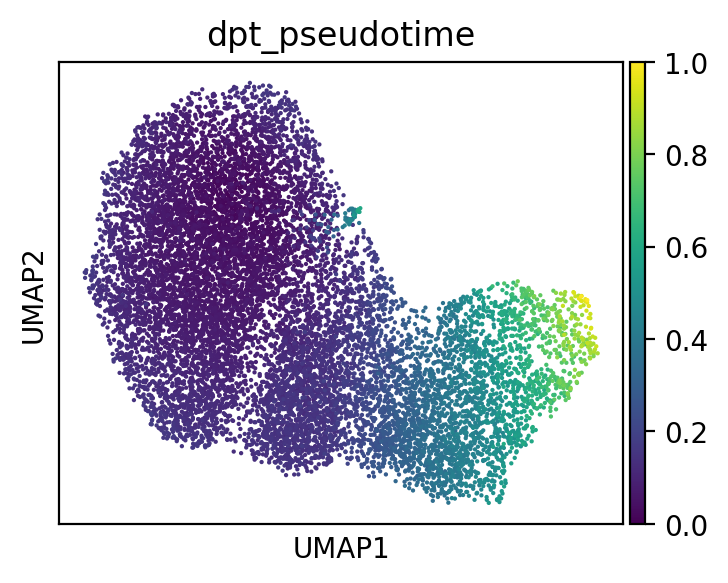

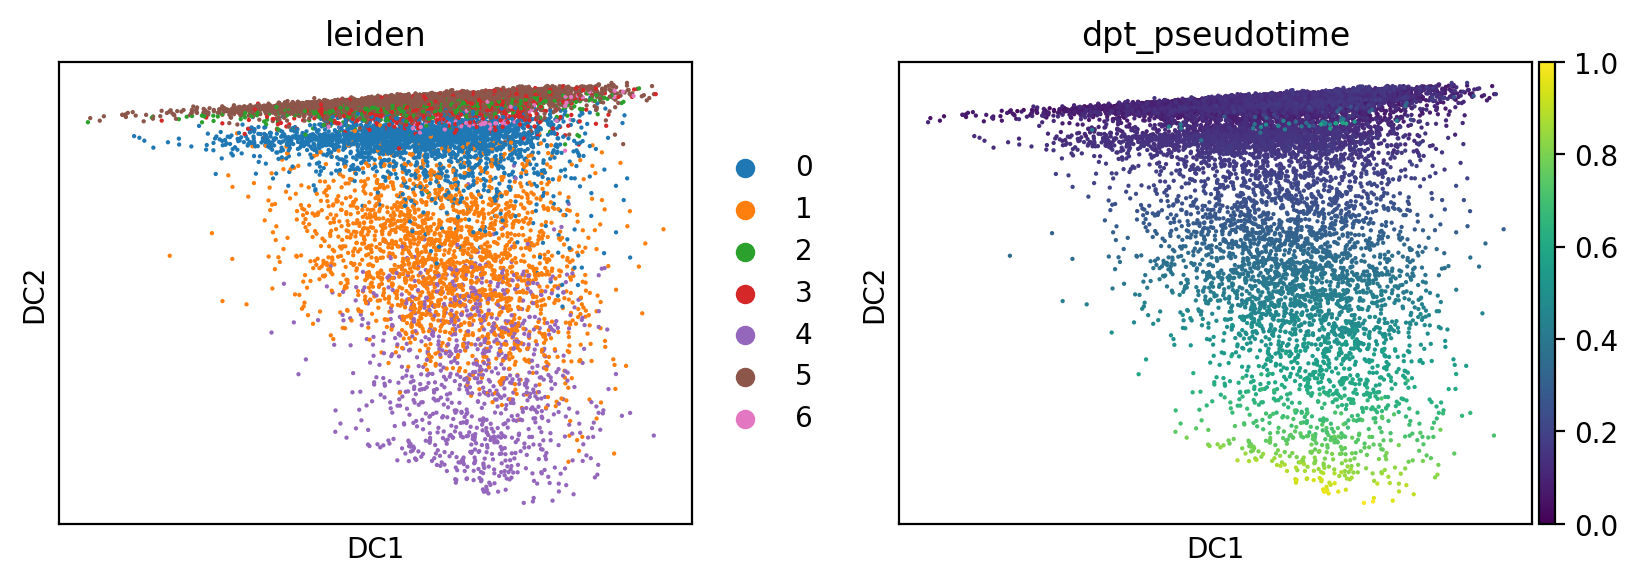

In [35]:
pdata.uns["iroot"] = root_idx

sc.tl.diffmap(pdata)
sc.tl.dpt(pdata, n_dcs=15)
    
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 3

sc.pl.umap(pdata, color='dpt_pseudotime', color_map='viridis')
sc.pl.diffmap(pdata, color=['leiden', 'dpt_pseudotime'], ncols=2)

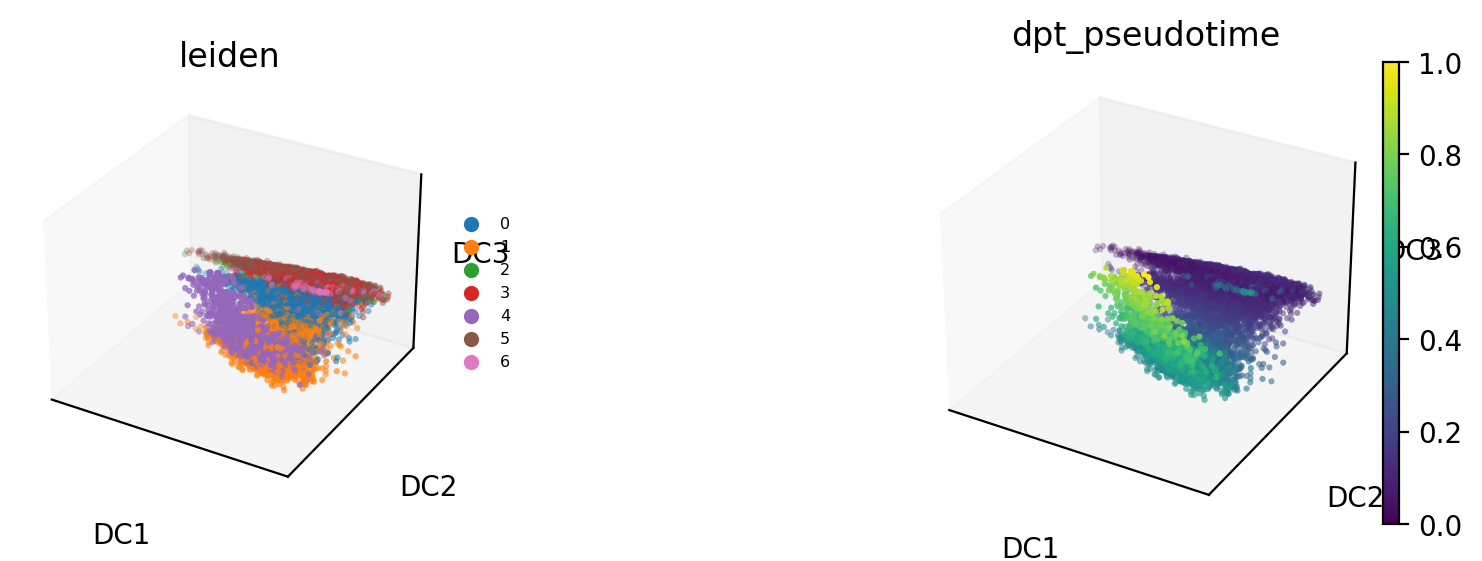

In [37]:
sc.pl.diffmap(
    pdata,
    color=['leiden', 'dpt_pseudotime'],
    ncols=2,
    projection='3d',
    legend_fontsize='xx-small',
)

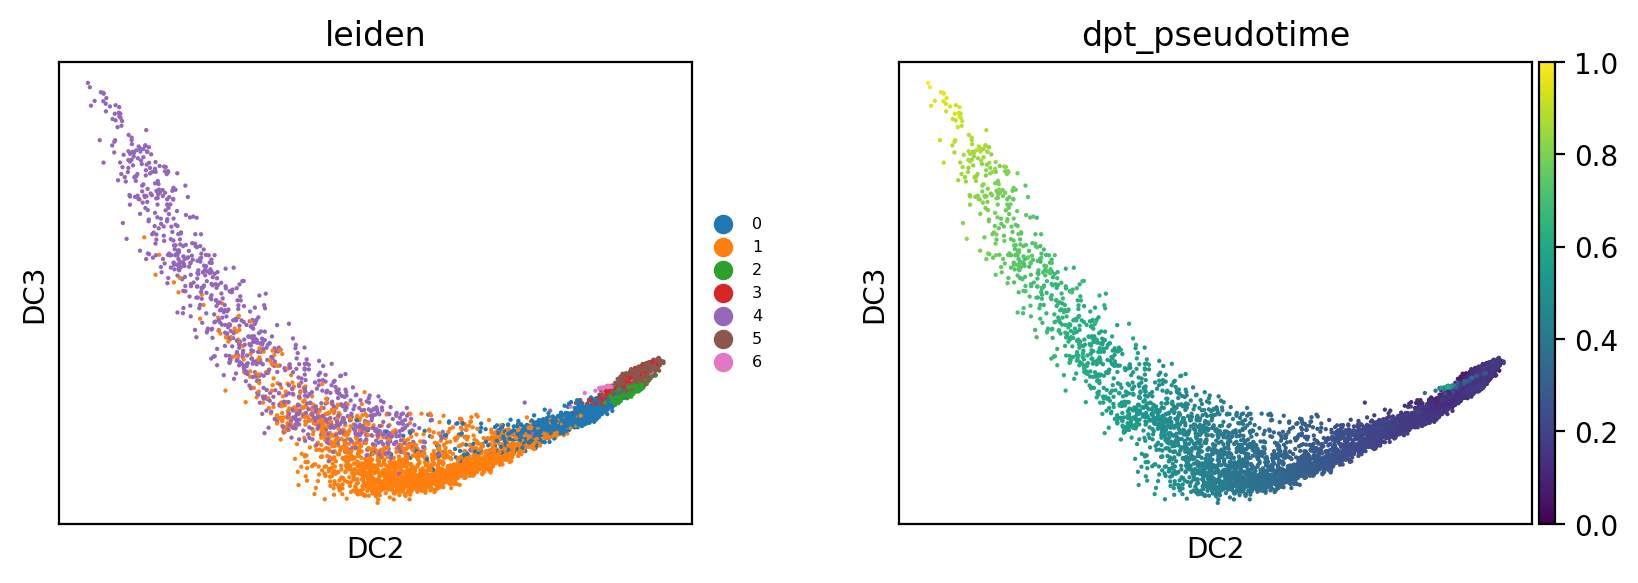

In [39]:
sc.pl.diffmap(
    pdata,
    color=['leiden', 'dpt_pseudotime'],
    ncols=2,
    projection='2d',
    components=['2,3'],
    legend_fontsize='xx-small',
)

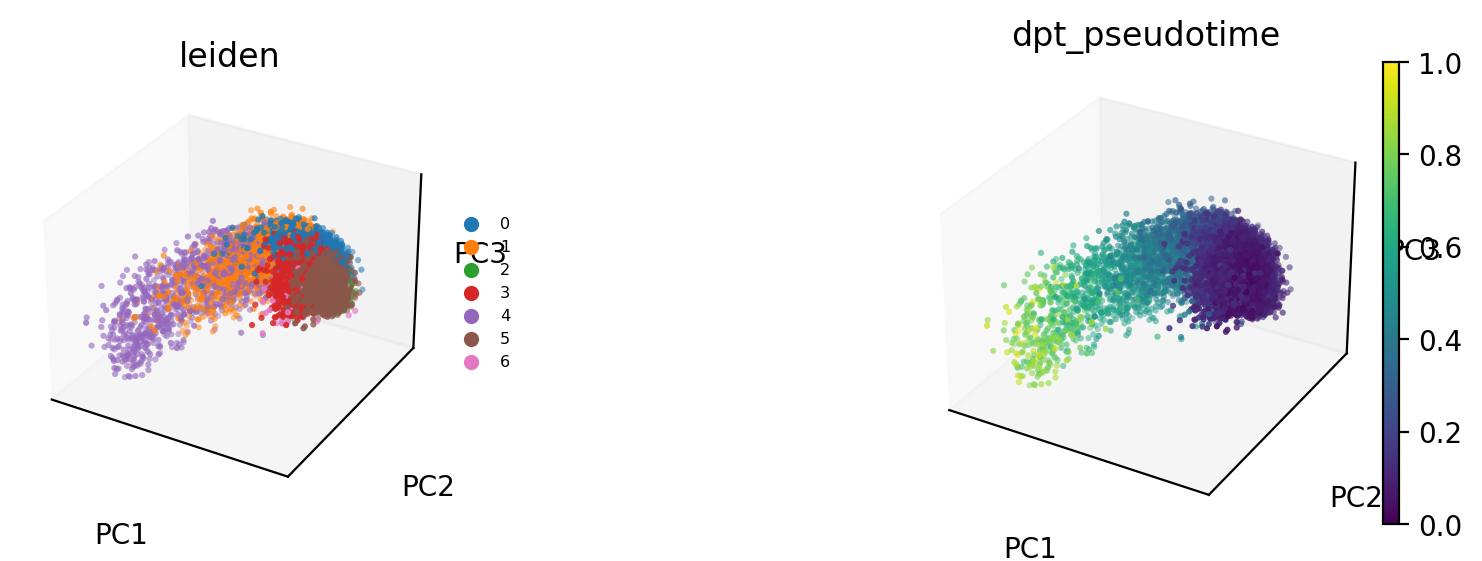

In [41]:
sc.pl.pca(
    pdata,
    color=['leiden', 'dpt_pseudotime'],
    ncols=2,
    projection='3d',
    # components=['2,3'],
    legend_fontsize='xx-small',
)

computing UMAP
    finished (0:00:11)


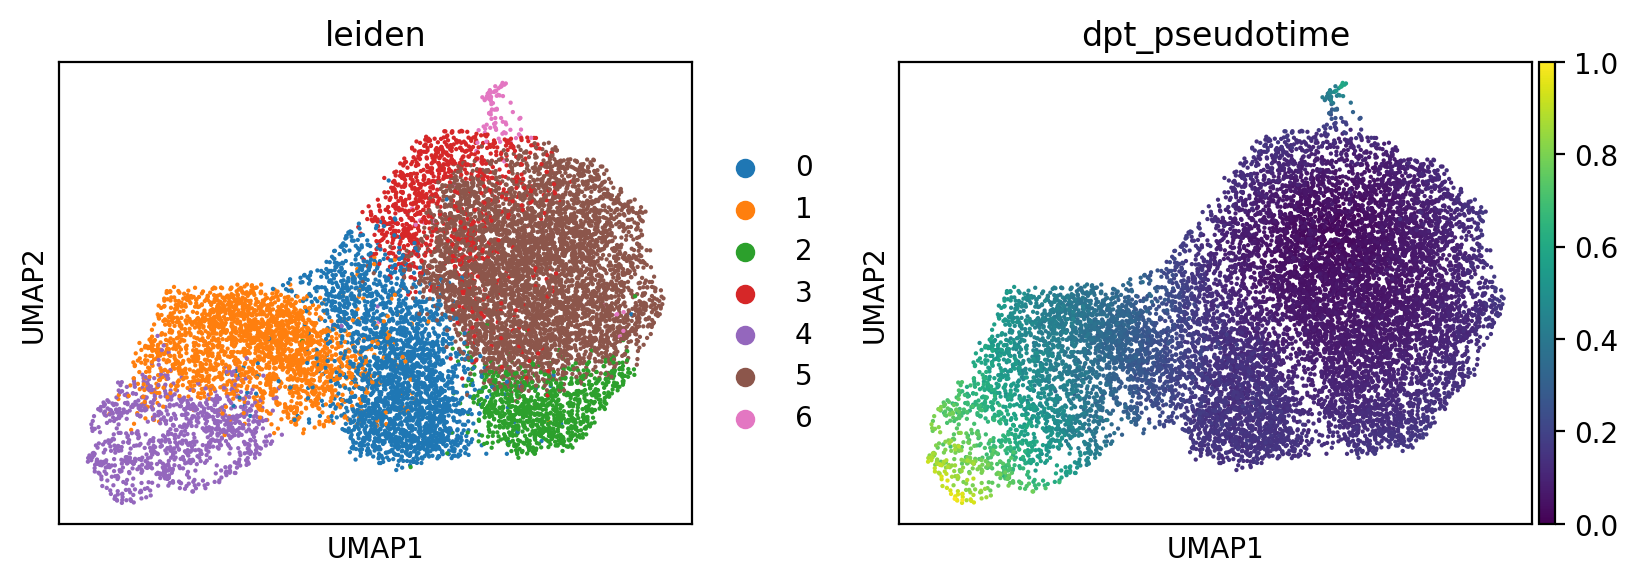

In [40]:
sc.tl.umap(pdata, init_pos='paga')
# sc.pl.paga(pdata, threshold=0.05, show=True)
sc.pl.umap(pdata, color=['leiden', 'dpt_pseudotime'])

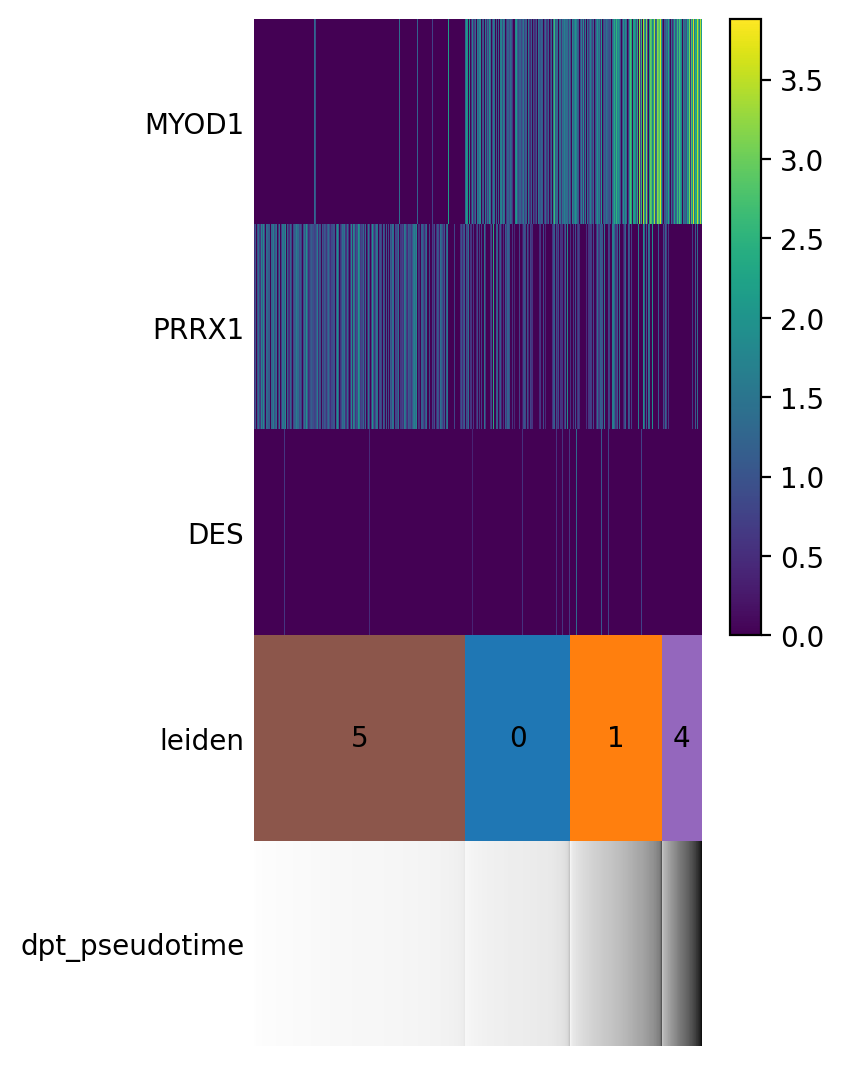

In [25]:
sc.pl.paga_path(
    pdata,
    nodes=['5', '0', '1', '4'],   # lineage path through clusters
    keys=['MYOD1', 'PRRX1', 'DES'],
    show=True,
    use_raw=False,
)